In [2]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.feature_selection import mutual_info_regression, mutual_info_classif
from scipy.stats import pearsonr
from statannotations.Annotator import Annotator
from Bio.SeqUtils.ProtParam import ProteinAnalysis

metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
metrics_df["closest_ab_pident"] = metrics_df["closest_ab_pident"].fillna(0)
metrics_df["ubiquitin_pident"] = metrics_df["ubiquitin_pident"].fillna(0)

results_df = pd.read_csv("../data/12k_all_results.csv")
results_df["leah_12k_isup"] = results_df["leah_12k_2fold_threshold"] == "Up"
results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)
results_df["leah_12k_twist_dna_detected"] = results_df["twist_dna_read_percentile"].apply(lambda x: x > 0)
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)




# results_df.columns
# results_df["leah_12k_2fold_threshold"].fillna("Not Sig") # I don't think we can fill the rest! and im not even sure this is valid

# # print cols with nan values
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(f"{col}: {metrics_df[col].isna().sum()}")

# # describe each value too
# for col in metrics_df.columns:
#     if metrics_df[col].isna().sum() > 0:
#         print(metrics_df[col].describe())
#         print()
#         print()

/tmp/ipykernel_3136174/1254283818.py:12: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  metrics_df = pd.read_csv("../data/12k_all_metrics.csv")
/tmp/ipykernel_3136174/1254283818.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  results_df["leah_12k_Significant"] = results_df["leah_12k_Significant"].fillna(False)


In [3]:
results_df.columns.tolist()

['global_id',
 'sequence',
 'leah_12k_N6_1',
 'leah_12k_R6_1',
 'leah_12k_N6_2',
 'leah_12k_R6_2',
 'leah_12k_N6_3',
 'leah_12k_R6_3',
 'dna_sequence',
 'twist_dna_read_percentile',
 'leah_12k_logFC',
 'leah_12k_logCPM',
 'leah_12k_LR',
 'leah_12k_PValue',
 'leah_12k_FDR',
 'leah_12k_2fold_threshold',
 'leah_12k_Significant',
 'leah_12k_final_score',
 'leah_12k_detected',
 'leah_top10_cytotox_AUC_R_CD20',
 'leah_top10_cytotox_AUC_K_Control',
 'leah_top10_fold_change_CTV_MFI_AUC_proliferation',
 'leah_top10_cytotox_AUC_R_minus_K',
 'leah_top10_percent_cytokine_positive',
 'leah_top10_fold_change_total_cell_count_per_well_expansion',
 'leah_top10_cytotox_AUC_R_minus_K_minmax_norm',
 'leah_top10_percent_cytokine_positive_minmax_norm',
 'leah_top10_fold_change_total_cell_count_per_well_expansion_minmax_norm',
 'leah_top10_sum_of_norms',
 'leah_12k_isup',
 'leah_12k_twist_dna_detected',
 'leah_12k_2fold_threshold_int']

In [4]:
human_freqs = {
    'A': 0.078,
    'C': 0.019,
    'D': 0.053,
    'E': 0.063,
    'F': 0.040,
    'G': 0.074,
    'H': 0.022,
    'I': 0.062,
    'K': 0.058,
    'L': 0.099,
    'M': 0.024,
    'N': 0.044,
    'P': 0.051,
    'Q': 0.034,
    'R': 0.052,
    'S': 0.070,
    'T': 0.058,
    'V': 0.065,
    'W': 0.013,
    'Y': 0.032,
}

def kl_between_seq_and_human(seq):
    """
    Compute KL divergence between the amino acid composition of seq
    and the human proteome frequencies.
    """
    pa = ProteinAnalysis(seq)
    freqs = pa.get_amino_acids_percent()

    kl_div = 0.0
    for aa in human_freqs.keys():
        p = freqs.get(aa, 0.0)
        q = human_freqs[aa]
        if p > 0:
            kl_div += p * math.log2(p / q)
    return kl_div

def compute_gravy(sequence: str) -> float:
    """
    Compute GRAVY (Grand Average of Hydropathy) for an amino acid sequence.
    """
    seq = sequence.replace("*", "").upper()  # remove stop if present
    analyzed_seq = ProteinAnalysis(seq)
    return analyzed_seq.gravy()

def sequence_complexity(seq):
    """
    Shannon entropy over amino acid frequencies.
    Higher entropy means higher complexity.
    """
    seq = seq.replace("*", "").upper()
    pa = ProteinAnalysis(seq)
    freqs = pa.get_amino_acids_percent()

    entropy = 0.0
    for aa, p in freqs.items():
        if p > 0:
            entropy += -p * math.log2(p)
    return entropy

def dna_sequence_entropy(seq):
    """
    Shannon entropy over nucleotide frequencies.
    Higher entropy means higher complexity.
    """
    seq = seq.upper()
    length = len(seq)
    freqs = Counter(seq)
    
    entropy = 0.0
    for nucleotide, count in freqs.items():
        p = count / length
        if p > 0:
            entropy += -p * math.log2(p)
    return entropy

def num_cysteines(seq):
    """
    Count the number of cysteine residues in the sequence.
    """
    seq = seq.replace("*", "").upper()
    return seq.count('C')

def compute_charge(sequence: str) -> float:
    """
    Compute the net charge of an amino acid sequence at pH 7.0.
    """
    seq = sequence.replace("*", "").upper()  # remove stop if present
    analyzed_seq = ProteinAnalysis(seq)
    return analyzed_seq.charge_at_pH(7.0)

def gc_content(sequence: str) -> float:
    """
    Compute the GC content of a DNA sequence.
    """
    sequence = sequence.upper()
    g_count = sequence.count('G')
    c_count = sequence.count('C')
    gc_count = g_count + c_count
    return gc_count / len(sequence) if len(sequence) > 0 else 0.0

def contains_linker(seq):
    linker_seqs = ["GGGGS", "GGGS", "GGS", "GGGGGS"]
    for linker in linker_seqs:
        if linker in seq:
            return True
    return False

def longest_duplicated_substring(seq):
    """
    Find the longest duplicated substring in the sequence such that
    the two defining occurrences do not overlap.

    Return: (length, substring, total_occurrences)
    where total_occurrences counts all (possibly overlapping) matches.
    """
    def count_overlapping(haystack, needle):
        if not needle:
            return 0
        count = 0
        i = 0
        while True:
            i = haystack.find(needle, i)
            if i == -1:
                break
            count += 1
            i += 1  # move by 1 to allow overlaps
        return count

    n = len(seq)
    suffixes = sorted((seq[i:], i) for i in range(n))

    max_len = 0
    best_substring = ""

    for i in range(1, n):
        s1, idx1 = suffixes[i - 1]
        s2, idx2 = suffixes[i]

        # compute LCP between neighboring suffixes
        j = 0
        limit = min(len(s1), len(s2))
        while j < limit and s1[j] == s2[j]:
            j += 1

        # prevent overlap between the two suffixes used to define the match
        distance = abs(idx1 - idx2)
        lcp_no_overlap = min(j, distance)

        if lcp_no_overlap > max_len:
            max_len = lcp_no_overlap
            start = min(idx1, idx2)
            best_substring = seq[start:start + max_len]

    if max_len == 0:
        return 0, "", 0

    total_occurrences = count_overlapping(seq, best_substring)
    return max_len, best_substring, total_occurrences


metrics_df["gravy_score"] = metrics_df["sequence"].apply(compute_gravy)
metrics_df["aa_sequence_entropy"] = metrics_df["sequence"].apply(sequence_complexity)
metrics_df["dna_sequence_entropy"] = results_df["dna_sequence"].apply(dna_sequence_entropy)
metrics_df["num_cysteines"] = metrics_df["sequence"].apply(num_cysteines)
metrics_df["seq_kl_vs_human"] = metrics_df["sequence"].apply(kl_between_seq_and_human)
metrics_df["seq_charge"] = metrics_df["sequence"].apply(compute_charge)
metrics_df["dna_gc_content"] = results_df["dna_sequence"].apply(gc_content)
metrics_df["is_linker"] = metrics_df["sequence"].apply(contains_linker)
metrics_df[["longest_dup_substr_len", "longest_dup_substr", "longest_dup_occurrences"]] = metrics_df["sequence"].apply(
    lambda seq: pd.Series(longest_duplicated_substring(seq))
)
metrics_df["total_duplicated_residues"] = metrics_df["longest_dup_substr_len"] * metrics_df["longest_dup_occurrences"]


/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/Bio/SeqUtils/ProtParam.py:106: BiopythonDeprecationWarning: The get_amino_acids_percent method has been deprecated and will likely be removed from Biopython in the near future. Please use the amino_acids_percent attribute instead.
  warnings.warn(
/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/Bio/SeqUtils/ProtParam.py:106: BiopythonDeprecationWarning: The get_amino_acids_percent method has been deprecated and will likely be removed from Biopython in the near future. Please use the amino_acids_percent attribute instead.
  warnings.warn(


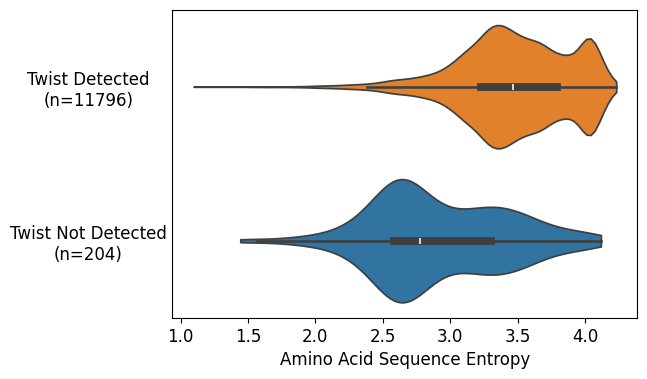

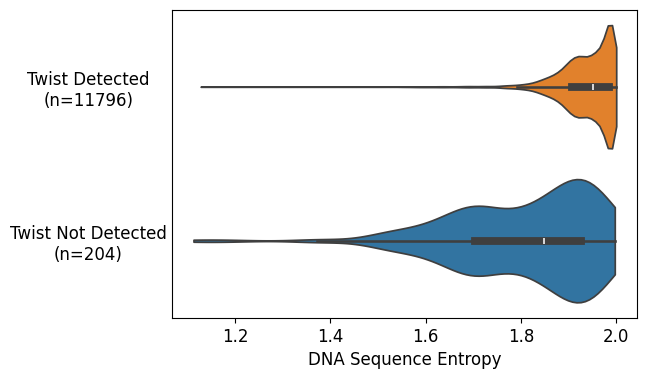

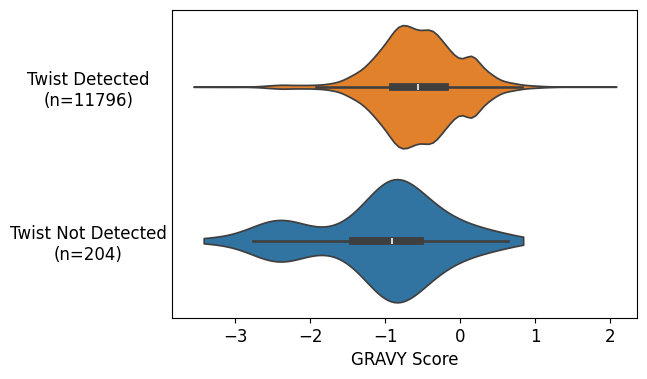

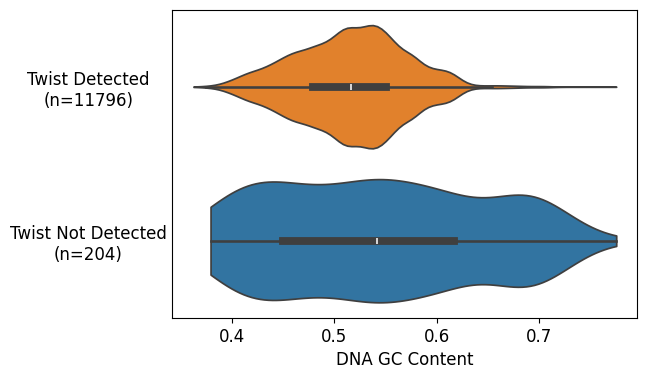

In [5]:
# make a simple violin plot: metrics vs leah_12k_twist_dna_detected

def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
):
    """
    Make a violin plot of a feature vs an arbitrary target column in results_df.

    Parameters
    ----------
    feature : str
        Column name in metrics_df.
    target_col : str
        Column name in results_df (binary or multiclass).
    save_dir : str
        Directory to save the figure.
    class_order : list, optional
        Explicit ordering of target classes. If None, uses value_counts order.
    class_palette : dict or list, optional
        Passed to seaborn as the palette; can be a mapping from class to color.
    feature_labels_map : dict, optional
        Mapping from feature name to prettier x label. If None, uses global
        feature_labels if available, otherwise uses the raw feature name.
    """
    # values for the feature
    feature_vals = metrics_df[feature].dropna()

    # align target on same index
    target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    if y_labels_map is not None:
        new_labels = [y_labels_map.get(lab, lab) + f"\n(n={counts[lab]})" for lab in class_order]
        # remove y axis label
        ax.set_ylabel("")
    else:
        new_labels = [f"{lab}\n(n={counts[lab]})" for lab in class_order]
        ax.set_ylabel(target_col)
    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left (similar to your existing function)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    feature_safe = feature.replace(" ", "_")
    target_safe = target_col.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()


# binary target



for feature in ["aa_sequence_entropy", "dna_sequence_entropy", "gravy_score","dna_gc_content",]:
    plot_feature_violin_generic(
        feature=feature,
        target_col="leah_12k_twist_dna_detected",
        feature_labels_map={"aa_sequence_entropy": "Amino Acid Sequence Entropy", "gravy_score": "GRAVY Score", "dna_gc_content": "DNA GC Content", "dna_sequence_entropy": "DNA Sequence Entropy",},
        class_order=[True, False],
        # true orange false blue (original matplotlib colors)
        class_palette={True: "#ff7f0e", False: "#1f77b4"},
        y_labels_map={True: "Twist Detected", False: "Twist Not Detected"},
    )

# # multiclass target with custom order and palette
# my_order = ["class_A", "class_B", "class_C"]
# my_palette = {
#     "class_A": "#009E73",
#     "class_B": "#D55E00",
#     "class_C": "#0072B2",
# }
# plot_feature_violin_generic(
#     feature="aa_sequence_entropy",
#     target_col="my_multiclass_col",
#     class_order=my_order,
#     class_palette=my_palette,
# )

In [6]:
# cols = metrics_df.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()
# # y_metric = "leah_12k_detected"
# y_metric = "twist_dna_read_percentile"

# mi_df = pd.DataFrame()
# for col in cols:
#     pre_len = len(metrics_df)
#     metrics_df_col = metrics_df[[col]].copy()
#     metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
#     post_len = len(metrics_df_col)
#     X = metrics_df_col[col].values.reshape(-1, 1)
#     y = results_df.loc[metrics_df_col.index, y_metric].values
#     # mi = mutual_info_classif(
#     #     X,
#     #     y,
#     #     random_state=8387234,
#     #     # n_neighbors=5,
#     #     # discrete_features=False,
#     # )
#     mi = mutual_info_regression(
#         X,
#         y,
#         random_state=8387234,
#         # n_neighbors=5,
#         # discrete_features=False,
#     )
#     sub_df = pd.DataFrame({
#         "metric": col,
#         f"mi_vs_{y_metric}": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })
#     mi_df = pd.concat([mi_df, sub_df], axis=0)
# mi_df = mi_df.sort_values(f"mi_vs_{y_metric}", ascending=False).reset_index(drop=True)
# mi_df
# # mi_df.to_csv("../results/analysis/feature_mi_vs_leah_12k_detected.csv", index=False)

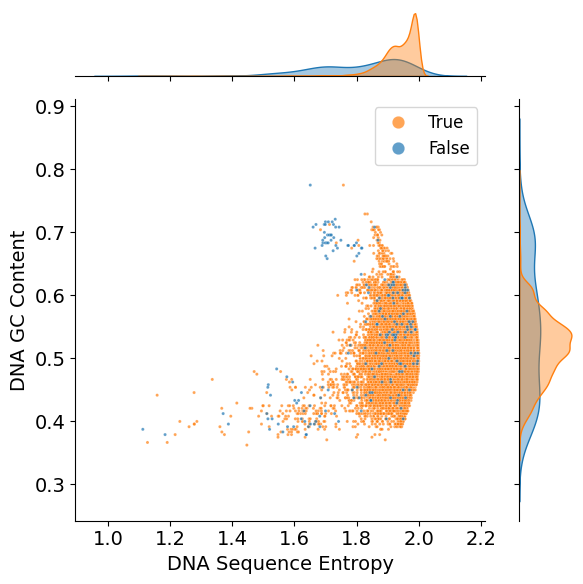

In [7]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def map_four_class_int_to_label(v):
    if pd.isna(v):
        return "Not Detected"
    if v == 0:
        return "Detected (Not Sig)"
    if v == 1:
        return "Detected (Up)"
    if v == -1:
        return "Detected (Down)"
    return "Not Detected"


def ensure_fourclass(results_df):
    if "leah_12k_2fold_threshold_int" not in results_df.columns:
        results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
            {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
        )
    if "fourclass" not in results_df.columns:
        results_df["fourclass"] = results_df["leah_12k_2fold_threshold_int"].apply(
            map_four_class_int_to_label
        )
    return results_df


def pretty_label(name):
    return (
        name.replace("_", " ")
            .title()
            .replace("Ll", "Log Likelihood")
            .replace("Car", "CAR")
            .replace("Esm", "ESM")
            .replace("Bc", "BC")
            .replace("Gc", "GC")
            .replace("Dna", "DNA")
    )


def plot_joint_two_features(
    feat_x,
    feat_y,
    metrics_df,
    results_df,
    hue_col="fourclass",          # e.g. "fourclass" or "leah_12k_detected"
    hue_order=None,
    palette=None,
    out_path=None,
):
    # ensure fourclass exists if requested
    if hue_col == "fourclass":
        results_df = ensure_fourclass(results_df)

    # base plotting df
    # add any extras you care about here if needed
    plot_df = metrics_df[[feat_x, feat_y]].copy()
    plot_df = plot_df.dropna(subset=[feat_x, feat_y])
    

    # attach hue column from results_df
    if hue_col == "fourclass":
        h = results_df.loc[plot_df.index, "fourclass"]
        plot_df["hue"] = h
    elif hue_col == "leah_12k_detected":
        # map to nicer labels
        h_raw = results_df.loc[plot_df.index, "leah_12k_detected"].astype(bool)
        plot_df["hue"] = np.where(h_raw, "Detected", "Not Detected")
    else:
        # generic: directly copy that column
        h = results_df.loc[plot_df.index, hue_col]
        plot_df["hue"] = h

    # drop rows with missing hue
    plot_df = plot_df[plot_df["hue"].notna()]

    # default orders and palettes if not provided
    if hue_col == "fourclass":
        default_order = [
            "Not Detected",
            "Detected (Not Sig)",
            "Detected (Up)",
            "Detected (Down)",
        ]
        default_palette = {
            "Detected (Down)": "#009E73",
            "Detected (Not Sig)": "#D55E00",
            "Detected (Up)": "#0072B2",
            "Not Detected": "#F0E442",
        }
        # sort to have nicer layering
        cat_order = {
            "Not Detected": 0,
            "Detected (Not Sig)": 1,
            "Detected (Up)": 2,
            "Detected (Down)": 3,
        }
        plot_df = plot_df.assign(sort_key=plot_df["hue"].map(cat_order))
        plot_df = plot_df.sort_values("sort_key", ascending=True)
    elif hue_col == "leah_12k_detected":
        default_order = ["Detected", "Not Detected"]
        default_palette = {
            "Detected": "#0072B2",
            "Not Detected": "#D55E00",
        }
    else:
        # fall back to sorted unique values and let seaborn choose colors
        default_order = sorted(plot_df["hue"].unique())
        default_palette = None

    if hue_order is None:
        hue_order = default_order
    if palette is None:
        palette = default_palette

    plot_df = plot_df.sort_values(by="hue", ascending=False)

    g = sns.jointplot(
        data=plot_df,
        x=feat_x,
        y=feat_y,
        hue="hue",
        hue_order=hue_order,
        palette=palette,
        kind="scatter",
        s=5,
        alpha=0.7,
        marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
    )

    # pretty axis labels
    g.ax_joint.set_xlabel(pretty_label(feat_x), fontsize=14)
    g.ax_joint.set_ylabel(pretty_label(feat_y), fontsize=14)

    g.ax_joint.tick_params(axis="x", labelsize=14)
    g.ax_joint.tick_params(axis="y", labelsize=14)

    

    # legend with larger markers in the right order
    leg = g.ax_joint.get_legend()
    handles = leg.legend_handles
    g.ax_joint.legend(
        handles,
        hue_order,
        markerscale=4,
        fontsize=12,
        title="",
    )

    plt.tight_layout()

    if out_path is None:
        out_path = f"../results/analysis/joint_{feat_x}_{feat_y}_by_{hue_col}.png"

    plt.savefig(out_path, dpi=300)
    # plt.close(g.fig)

# color by binary leah_12k_detected (mapped to "Detected"/"Not Detected")
plot_joint_two_features(
    "dna_sequence_entropy",
    "dna_gc_content",
    metrics_df,
    results_df,
    hue_col="leah_12k_twist_dna_detected",
    hue_order=[True, False],
    palette={True: "#ff7f0e", False: "#1f77b4"},
)

In [8]:
# remove rows where twist dna not detected (results and metrics)
metrics_df = metrics_df.loc[results_df["leah_12k_twist_dna_detected"] == True].copy()
results_df = results_df.loc[results_df["leah_12k_twist_dna_detected"] == True].copy()
metrics_df = metrics_df.reset_index(drop=True)
results_df = results_df.reset_index(drop=True)

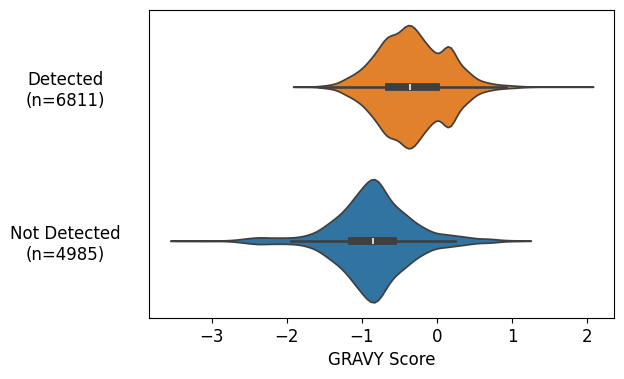

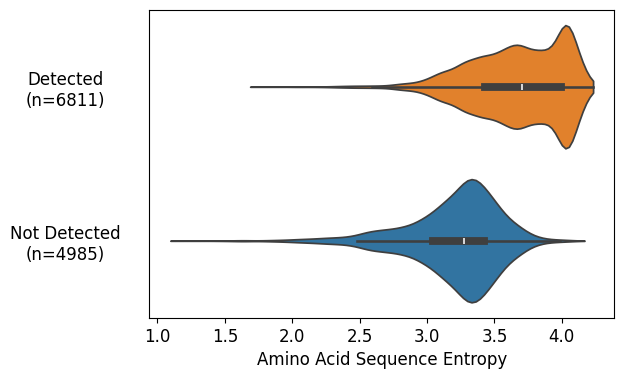

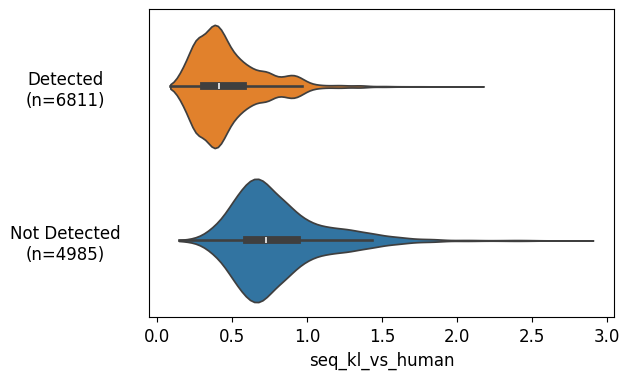

In [9]:
# make a simple violin plot: metrics vs leah_12k_detected

def plot_feature_violin_generic(
    feature,
    target_col,
    save_dir="../results/analysis",
    class_order=None,
    class_palette=None,
    feature_labels_map=None,
    y_labels_map=None,
):
    """
    Make a violin plot of a feature vs an arbitrary target column in results_df.

    Parameters
    ----------
    feature : str
        Column name in metrics_df.
    target_col : str
        Column name in results_df (binary or multiclass).
    save_dir : str
        Directory to save the figure.
    class_order : list, optional
        Explicit ordering of target classes. If None, uses value_counts order.
    class_palette : dict or list, optional
        Passed to seaborn as the palette; can be a mapping from class to color.
    feature_labels_map : dict, optional
        Mapping from feature name to prettier x label. If None, uses global
        feature_labels if available, otherwise uses the raw feature name.
    """
    # values for the feature
    feature_vals = metrics_df[feature].dropna()

    # align target on same index
    target_vals = results_df.loc[feature_vals.index, target_col]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "target": target_vals,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "target"])

    # build class order
    if class_order is None:
        class_order = df["target"].value_counts().index.tolist()

    # make sure target is treated as categorical with the requested order
    df["target"] = pd.Categorical(df["target"], categories=class_order, ordered=True)

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="target",
        orient="h",
        order=class_order,
        palette=class_palette,
        hue="target",
        ax=ax,
        cut=0,
        legend=False,
    )

    # counts for each class
    counts = (
        df["target"]
        .value_counts()
        .reindex(class_order)
        .fillna(0)
        .astype(int)
    )

    if y_labels_map is not None:
        new_labels = [y_labels_map.get(lab, lab) + f"\n(n={counts[lab]})" for lab in class_order]
        # remove y axis label
        ax.set_ylabel("")
    else:
        new_labels = [f"{lab}\n(n={counts[lab]})" for lab in class_order]
        ax.set_ylabel(target_col)
    ax.set_yticks(range(len(class_order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)

    # x label
    if feature_labels_map is None and "feature_labels" in globals():
        feature_labels_map = feature_labels

    xlabel = (
        feature_labels_map.get(feature, feature)
        if feature_labels_map is not None
        else feature
    )
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left (similar to your existing function)
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    feature_safe = feature.replace(" ", "_")
    target_safe = target_col.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_{target_safe}.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()


# binary target



for feature in ["gravy_score",
    "aa_sequence_entropy",
    "seq_kl_vs_human",]:
    plot_feature_violin_generic(
        feature=feature,
        target_col="leah_12k_detected",
        feature_labels_map={"aa_sequence_entropy": "Amino Acid Sequence Entropy", "gravy_score": "GRAVY Score", "dna_gc_content": "DNA GC Content", "dna_sequence_entropy": "DNA Sequence Entropy",},
        class_order=[True, False],
        # true orange false blue (original matplotlib colors)
        class_palette={True: "#ff7f0e", False: "#1f77b4"},
        y_labels_map={True: "Detected", False: "Not Detected"},
    )

# # multiclass target with custom order and palette
# my_order = ["class_A", "class_B", "class_C"]
# my_palette = {
#     "class_A": "#009E73",
#     "class_B": "#D55E00",
#     "class_C": "#0072B2",
# }
# plot_feature_violin_generic(
#     feature="aa_sequence_entropy",
#     target_col="my_multiclass_col",
#     class_order=my_order,
#     class_palette=my_palette,
# )

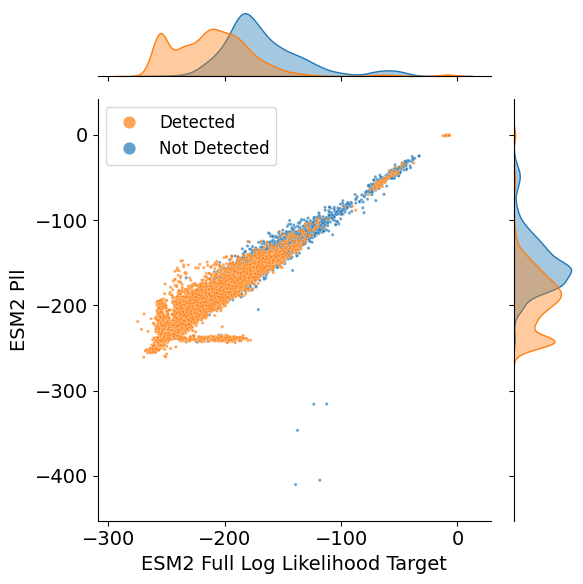

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def map_four_class_int_to_label(v):
    if pd.isna(v):
        return "Not Detected"
    if v == 0:
        return "Detected (Not Sig)"
    if v == 1:
        return "Detected (Up)"
    if v == -1:
        return "Detected (Down)"
    return "Not Detected"


def ensure_fourclass(results_df):
    if "leah_12k_2fold_threshold_int" not in results_df.columns:
        results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
            {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
        )
    if "fourclass" not in results_df.columns:
        results_df["fourclass"] = results_df["leah_12k_2fold_threshold_int"].apply(
            map_four_class_int_to_label
        )
    return results_df


def pretty_label(name):
    return (
        name.replace("_", " ")
            .title()
            .replace("Ll", "Log Likelihood")
            .replace("Car", "CAR")
            .replace("Esm", "ESM")
            .replace("Bc", "BC")
            .replace("Gc", "GC")
            .replace("Dna", "DNA")
    )


def plot_joint_two_features(
    feat_x,
    feat_y,
    metrics_df,
    results_df,
    hue_col="fourclass",          # e.g. "fourclass" or "leah_12k_detected"
    hue_order=None,
    palette=None,
    out_path=None,
):
    # ensure fourclass exists if requested
    if hue_col == "fourclass":
        results_df = ensure_fourclass(results_df)

    # base plotting df
    # add any extras you care about here if needed
    plot_df = metrics_df[[feat_x, feat_y]].copy()
    plot_df = plot_df.dropna(subset=[feat_x, feat_y])
    

    # attach hue column from results_df
    if hue_col == "fourclass":
        h = results_df.loc[plot_df.index, "fourclass"]
        plot_df["hue"] = h
    elif hue_col == "leah_12k_detected":
        # map to nicer labels
        h_raw = results_df.loc[plot_df.index, "leah_12k_detected"].astype(bool)
        plot_df["hue"] = np.where(h_raw, "Detected", "Not Detected")
    else:
        # generic: directly copy that column
        h = results_df.loc[plot_df.index, hue_col]
        plot_df["hue"] = h

    # drop rows with missing hue
    plot_df = plot_df[plot_df["hue"].notna()]

    # default orders and palettes if not provided
    if hue_col == "fourclass":
        default_order = [
            "Not Detected",
            "Detected (Not Sig)",
            "Detected (Up)",
            "Detected (Down)",
        ]
        default_palette = {
            "Detected (Down)": "#009E73",
            "Detected (Not Sig)": "#D55E00",
            "Detected (Up)": "#0072B2",
            "Not Detected": "#F0E442",
        }
        # sort to have nicer layering
        cat_order = {
            "Not Detected": 0,
            "Detected (Not Sig)": 1,
            "Detected (Up)": 2,
            "Detected (Down)": 3,
        }
        plot_df = plot_df.assign(sort_key=plot_df["hue"].map(cat_order))
        plot_df = plot_df.sort_values("sort_key", ascending=True)
    elif hue_col == "leah_12k_detected":
        default_order = ["Detected", "Not Detected"]
        default_palette = {
            "Detected": "#0072B2",
            "Not Detected": "#D55E00",
        }
    else:
        # fall back to sorted unique values and let seaborn choose colors
        default_order = sorted(plot_df["hue"].unique())
        default_palette = None

    if hue_order is None:
        hue_order = default_order
    if palette is None:
        palette = default_palette

    plot_df = plot_df.sort_values(by="hue", ascending=True)

    g = sns.jointplot(
        data=plot_df,
        x=feat_x,
        y=feat_y,
        hue="hue",
        hue_order=hue_order,
        palette=palette,
        kind="scatter",
        s=5,
        alpha=0.7,
        marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
    )

    # pretty axis labels
    g.ax_joint.set_xlabel(pretty_label(feat_x), fontsize=14)
    g.ax_joint.set_ylabel(pretty_label(feat_y), fontsize=14)

    g.ax_joint.tick_params(axis="x", labelsize=14)
    g.ax_joint.tick_params(axis="y", labelsize=14)

    

    # legend with larger markers in the right order
    leg = g.ax_joint.get_legend()
    handles = leg.legend_handles
    g.ax_joint.legend(
        handles,
        hue_order,
        markerscale=4,
        fontsize=12,
        title="",
    )

    plt.tight_layout()

    if out_path is None:
        out_path = f"../results/analysis/joint_{feat_x}_{feat_y}_by_{hue_col}.png"

    plt.savefig(out_path, dpi=300)
    # plt.close(g.fig)

# color by binary leah_12k_detected (mapped to "Detected"/"Not Detected")
plot_joint_two_features(
    "esm2_full_LL_target",
    "aa_sequence_entropy",
    metrics_df,
    results_df,
    hue_col="leah_12k_detected",
    hue_order=["Detected", "Not Detected"],
    # palette={True: "#ff7f0e", False: "#1f77b4"},
    palette={"Detected": "#ff7f0e", "Not Detected": "#1f77b4"},
)

In [11]:
# far right cluster
# all schoeder lab w/ 3-4 linkers

mask = (
    (metrics_df["esm2_full_LL_target"] > -30)
    # & (metrics_df["aa_sequence_entropy"] > 3.2)
)

print(metrics_df.loc[mask]["total_duplicated_residues"].value_counts())
# is linker
metrics_df.loc[mask][["global_id", "team", "sequence", "aa_sequence_entropy", "esm2_full_LL_target", "closest_ab", "ubiquitin_pident", "is_linker", "longest_dup_substr_len", "longest_dup_occurrences", "total_duplicated_residues", "longest_dup_substr"]].to_csv("../results/analysis/schoeder_cluster.csv", index=False)

# print # of hits
# results_df.loc[mask]["leah_12k_detected"]

total_duplicated_residues
60    21
66    18
72    11
63     5
64     2
80     2
76     1
Name: count, dtype: int64


In [12]:
# Zist Rayanesh cluster!
# has linkers

# esm2 > -150 and < 80
mask = (
    (metrics_df["esm2_full_LL_target"] > -90)
    & (metrics_df["esm2_full_LL_target"] < -30)
    & (metrics_df["aa_sequence_entropy"] > 3.2)
)

print(metrics_df.loc[mask]["total_duplicated_residues"].value_counts())
# is linker
metrics_df.loc[mask][["global_id", "team", "sequence", "aa_sequence_entropy", "esm2_full_LL_target", "closest_ab", "ubiquitin_pident", "is_linker", "longest_dup_substr_len", "longest_dup_occurrences", "total_duplicated_residues", "longest_dup_substr"]].to_csv("../results/analysis/zist_cluster.csv", index=False)

# print # of hits
# results_df.loc[mask]["leah_12k_detected"]

total_duplicated_residues
60    84
68    57
58    50
66    37
62    36
70     2
64     2
Name: count, dtype: int64


In [13]:
# find lowest gravy score when leah_12k_detected is True
metrics_df.loc[results_df[results_df["leah_12k_detected"] == True].index]["gravy_score"].min()

np.float64(-1.9187500000000004)

In [14]:
# results_df.loc[metrics_df[metrics_df["dna_sequence_entropy"] < 1.85].index]["leah_12k_detected"].value_counts()
results_df.loc[metrics_df[metrics_df["gravy_score"] < -1.919].index]["dna_sequence"]

1998     CATCACCAGAAGCAGGAGCTGAAGCAGAAGCAAGATGAGCTGCAGG...
2014     ATGACCCCCGAGGAACTTGAGAAAGAGCTGGAGGAGCGGAGTAAGC...
7200     TCCGAGGAGATTAAGAAGGACGAGGAGAAACAGAAGGAAGAAGCCA...
7230     GAGGAGAAGAAGAAAAAAGAAGAGGAGAGGAAAAAAAAGATTGAGG...
7431     GACAAAGAAATTGAAGAGGATGAGAAAAAGCAGAAGGAGGAGCAGA...
                               ...                        
10857    GAGGAGGAAAAGAAGAAAGAAGAGGAGGAAAGGAAAAAGAAGGAAG...
10870    GACAAACTGAAGGAGCTCTATGACAAAATGCAGGAGTATTACAAGA...
10888    GAAGAAGAAAAGAAAAAAAAGGAGGAGAAGCTCAAAGAGGAGGAGT...
10891    AAAAAAAAGGAAGAACTTAAGAAAAAGGCCAAAGAGATCGAGGAGG...
10894    AAAAAAGAGGAAGAAGAGAAGAAGAAAAAAGAAGAAGAGAAGAAGA...
Name: dna_sequence, Length: 208, dtype: object

In [15]:
results_df.loc[metrics_df[metrics_df["aa_sequence_entropy"] < 2].index]["leah_12k_detected"].value_counts()

leah_12k_detected
False    38
True      3
Name: count, dtype: int64

In [16]:
# ---------- shared setup ----------

y_metric = "fourclass"

def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Detected (Down)"
    if v == 0:
        return "Detected (Not Sig)"
    if v == 1:
        return "Detected (Up)"
    return "Not Detected"

order = [
    "Detected (Down)",
    "Detected (Not Sig)",
    "Detected (Up)",
    "Not Detected",
]

palette = {
    "Detected (Down)": "#009E73",
    "Detected (Not Sig)": "#D55E00",
    "Detected (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}

# optional prettier x labels
feature_labels = {
    "gravy_score": "GRAVY score",
    "aa_sequence_entropy": "Amino Acid Sequence Entropy",
    "num_cysteines": "Number of cysteines",
    "num_disulfide_within_chain": "Within chain disulfides",
    "num_disulfide_between_chain": "Between chain disulfides",
    "num_pipi_within_chain": "Within chain π–π contacts",
    "num_pipi_between_chain": "Between chain π–π contacts",
    "joint_score": "Joint Score",
    "seq_kl_vs_human": "KL divergence vs human proteome",
    "seq_charge": "Net Charge at pH 7.0",
}

# ids to highlight on the "Detected (Up)" row
highlight_ids = {1506, 5300, 5981, 3718, 2383, 3494}

# ---------- build joint_score and store in metrics_df ----------

# feat_list = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized"]
# sign_list = [1.0, -1.0]

# metrics_df_sub = metrics_df[feat_list].copy().dropna()
# metrics_df_norm = (metrics_df_sub - metrics_df_sub.mean()) / metrics_df_sub.std()
# joint_score = (metrics_df_norm.values * sign_list).sum(axis=1)

# # store on matching index
# metrics_df.loc[metrics_df_sub.index, "joint_score"] = joint_score

# ---------- helper to build per feature df ----------

def build_feature_df(feature):
    # values for that feature
    feature_vals = metrics_df[feature].dropna()

    # align targets on same index
    detected = results_df.loc[feature_vals.index, "leah_12k_detected"]
    threeclass = results_df.loc[feature_vals.index, "leah_12k_2fold_threshold_int"]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "detected": detected,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "detected"])

    df["threeclass"] = threeclass.loc[df.index]
    df["global_id"] = results_df.loc[df.index, "global_id"]
    df["fourclass"] = df["threeclass"].apply(map_four_class)

    return df

# ---------- plotting function for one feature ----------

def plot_feature_violin(feature, save_dir="../results/analysis"):
    df = build_feature_df(feature)

    # MI and Pearson vs detected
    X = df[feature].values.reshape(-1, 1)
    y = df["detected"].values

    mi_val = mutual_info_classif(
        X,
        y,
        random_state=169873,
    )[0]

    pearson_corr, pearson_pval = pearsonr(df[feature].values, y)

    print(
        f"{feature}: MI={mi_val:.3f}, "
        f"Pearson r={pearson_corr:.3f}, p={pearson_pval:.2e}"
    )

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="fourclass",
        orient="h",
        order=order,
        palette=palette,
        hue="fourclass",
        ax=ax,
        cut=0,
    )

    # restrict counts and stats to actually plotted data
    valid = df["fourclass"].notna() & df[feature].notna()
    dplot = df.loc[valid]

    counts = (
        dplot["fourclass"]
        .value_counts()
        .reindex(order)
        .fillna(0)
        .astype(int)
    )

    new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)
    ax.set_ylabel("")

    xlabel = feature_labels.get(feature, feature)
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # # highlight ids on the "Detected (Up)" row
    # if highlight_ids:
    #     mask_highlight = (
    #         (df["fourclass"] == "Detected (Up)")
    #         & df["global_id"].isin(highlight_ids)
    #         & df[feature].notna()
    #     )

    #     x_high = df.loc[mask_highlight, feature].values
    #     y_pos = order.index("Detected (Up)")

    #     ax.scatter(
    #         x_high,
    #         np.full_like(x_high, y_pos, dtype=float),
    #         marker="x",
    #         s=70,
    #         color="#39FF14",
    #         edgecolor="black",
    #         linewidth=0.4,
    #         zorder=10,
    #     )

    # statannotations
    pairs = [
        ("Detected (Down)", "Detected (Not Sig)"),
        ("Detected (Not Sig)", "Detected (Up)"),
        ("Detected (Up)", "Not Detected"),
    ]

    annotator = Annotator(
        ax,
        pairs,
        data=dplot,
        x=feature,
        y="fourclass",
        order=order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        comparisons_correction="BH",
        text_format="star",
        pvalue_thresholds=[
            (1e-4, "****"),
            (1e-3, "***"),
            (1e-2, "**"),
            (0.05, "*"),
            (1, "ns"),
        ],
        show_test_name=False,
        loc="outside",
        fontsize=11,
        hide_non_significant=False,
    )
    annotator.apply_and_annotate()

    feature_safe = feature.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_4class_detected.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close()

# ---------- run for all metrics ----------

metrics_list = [
    "gravy_score",
    "aa_sequence_entropy",
    "num_disulfide_within_chain",
    "seq_kl_vs_human",
    # "num_cysteines",
    # "num_disulfide_between_chain",
    # "num_pipi_within_chain",
    # "num_pipi_between_chain",
    # "joint_score",
    # "seq_charge",
]

for feature in metrics_list:
    plot_feature_violin(feature)

gravy_score: MI=0.151, Pearson r=0.473, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Detected (Down) vs. Detected (Not Sig): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.450e-03 U_stat=4.215e+05
Detected (Not Sig) vs. Detected (Up): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.620e-40 U_stat=2.737e+06
Detected (Up) vs. Not Detected: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.339e-73 U_stat=2.504e+06
aa_sequence_entropy: MI=0.226, Pearson r=0.548, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Detected (Down) vs. Detected (Not Sig): Mann-Whitney-Wilcoxon test two-sided w

gravy_score: MI=0.151, Pearson r=0.473, p=0.00e+00


p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Detected (Down) vs. Detected (Not Sig): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.450e-03 U_stat=4.215e+05
Detected (Not Sig) vs. Detected (Up): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:6.620e-40 U_stat=2.737e+06
Detected (Up) vs. Not Detected: Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:1.339e-73 U_stat=2.504e+06
aa_sequence_entropy: MI=0.226, Pearson r=0.548, p=0.00e+00
p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Detected (Down) vs. Detected (Not Sig): Mann-Whitney-Wilcoxon test two-sided with Benjamini-Hochberg correction, P_val:5.914e-28

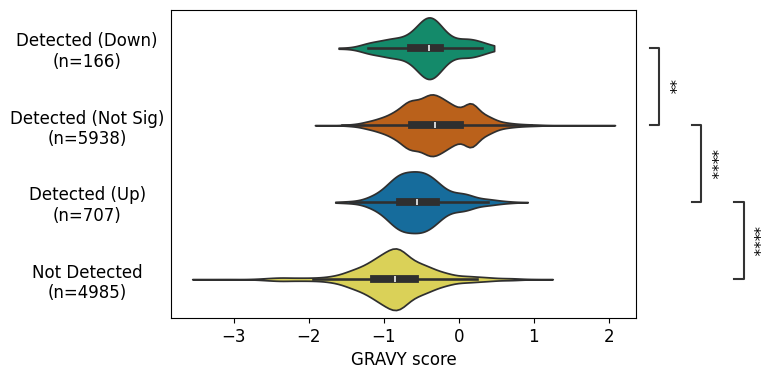

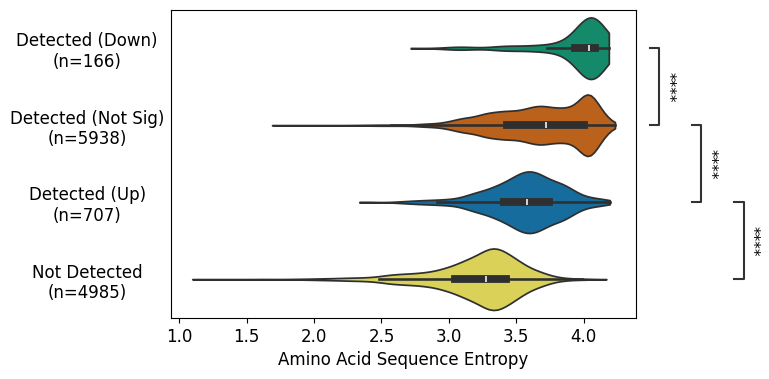

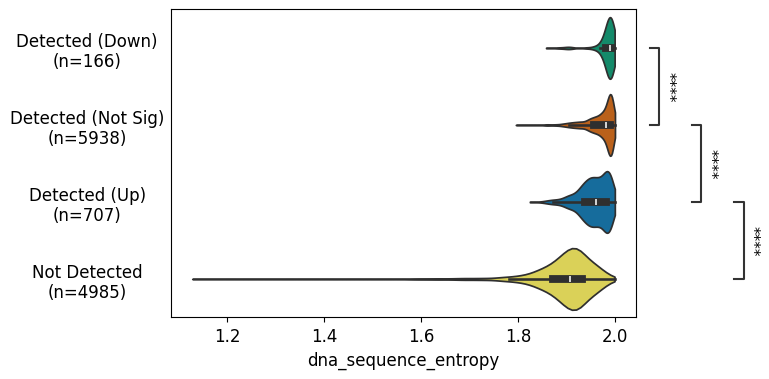

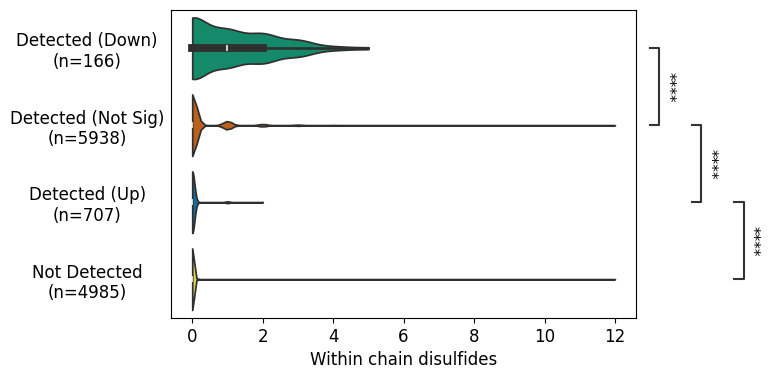

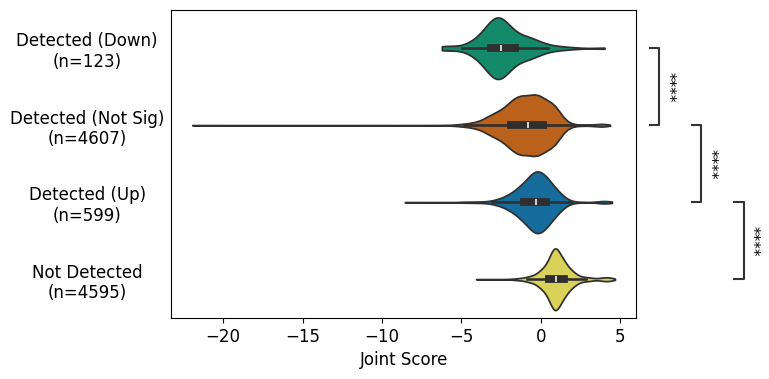

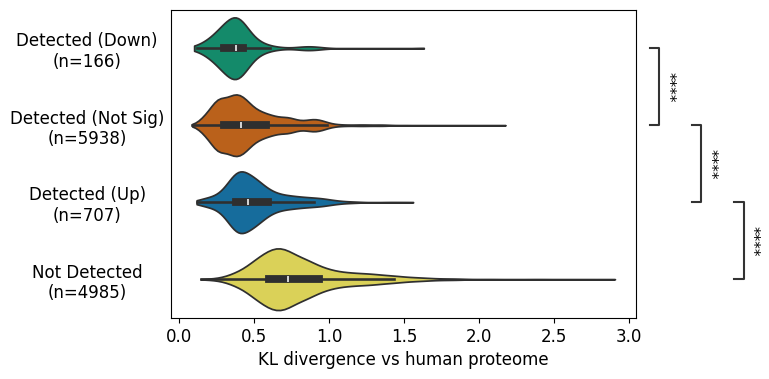

In [17]:
# ---------- shared setup ----------


# integer up/down/not sig mapping
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Detected (Down)"
    if v == 0:
        return "Detected (Not Sig)"
    if v == 1:
        return "Detected (Up)"
    return "Not Detected"

order = [
    "Detected (Down)",
    "Detected (Not Sig)",
    "Detected (Up)",
    "Not Detected",
]

palette = {
    "Detected (Down)": "#009E73",
    "Detected (Not Sig)": "#D55E00",
    "Detected (Up)": "#0072B2",
    "Not Detected": "#F0E442",
}

# optional prettier x labels
feature_labels = {
    "gravy_score": "GRAVY score",
    "aa_sequence_entropy": "Amino Acid Sequence Entropy",
    "num_cysteines": "Number of cysteines",
    "num_disulfide_within_chain": "Within chain disulfides",
    "num_disulfide_between_chain": "Between chain disulfides",
    "num_pipi_within_chain": "Within chain π–π contacts",
    "num_pipi_between_chain": "Between chain π–π contacts",
    "joint_score": "Joint Score",
    "seq_kl_vs_human": "KL divergence vs human proteome",
    "seq_charge": "Net Charge at pH 7.0",
}

# ids to highlight on the "Detected (Up)" row
highlight_ids = {1506, 5300, 5981, 3718, 2383, 3494}

# ---------- build joint_score and store in metrics_df ----------

feat_list = ["esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized"]
sign_list = [1.0, -1.0]

metrics_df_sub = metrics_df[feat_list].copy().dropna()
metrics_df_norm = (metrics_df_sub - metrics_df_sub.mean()) / metrics_df_sub.std()
joint_score = (metrics_df_norm.values * sign_list).sum(axis=1)

# store on matching index
metrics_df.loc[metrics_df_sub.index, "joint_score"] = joint_score

# ---------- helper to build per feature df ----------

def build_feature_df(feature):
    # values for that feature
    feature_vals = metrics_df[feature].dropna()

    # align targets on same index
    detected = results_df.loc[feature_vals.index, "leah_12k_detected"]
    threeclass = results_df.loc[feature_vals.index, "leah_12k_2fold_threshold_int"]

    df = pd.DataFrame(
        {
            feature: feature_vals,
            "detected": detected,
        },
        index=feature_vals.index,
    ).dropna(subset=[feature, "detected"])

    df["threeclass"] = threeclass.loc[df.index]
    df["global_id"] = results_df.loc[df.index, "global_id"]
    df["fourclass"] = df["threeclass"].apply(map_four_class)

    return df

# ---------- plotting function for one feature ----------

def plot_feature_violin(feature, save_dir="../results/analysis"):
    df = build_feature_df(feature)

    # MI and Pearson vs detected
    X = df[feature].values.reshape(-1, 1)
    y = df["detected"].values

    mi_val = mutual_info_classif(
        X,
        y,
        random_state=169873,
    )[0]

    pearson_corr, pearson_pval = pearsonr(df[feature].values, y)

    print(
        f"{feature}: MI={mi_val:.3f}, "
        f"Pearson r={pearson_corr:.3f}, p={pearson_pval:.2e}"
    )

    # plotting
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(6, 4))

    sns.violinplot(
        data=df,
        x=feature,
        y="fourclass",
        orient="h",
        order=order,
        palette=palette,
        hue="fourclass",
        ax=ax,
        cut=0,
    )

    # restrict counts and stats to actually plotted data
    valid = df["fourclass"].notna() & df[feature].notna()
    dplot = df.loc[valid]

    counts = (
        dplot["fourclass"]
        .value_counts()
        .reindex(order)
        .fillna(0)
        .astype(int)
    )

    new_labels = [f"{lab}\n(n={counts[lab]})" for lab in order]
    ax.set_yticks(range(len(order)))
    ax.set_yticklabels(new_labels)

    ax.tick_params(axis="y", length=0)
    ax.set_ylabel("")

    xlabel = feature_labels.get(feature, feature)
    ax.set_xlabel(xlabel)

    # center y tick labels and shift left
    for label in ax.get_yticklabels():
        label.set_horizontalalignment("center")
        label.set_x(-0.17)

    # # highlight ids on the "Detected (Up)" row
    # if highlight_ids:
    #     mask_highlight = (
    #         (df["fourclass"] == "Detected (Up)")
    #         & df["global_id"].isin(highlight_ids)
    #         & df[feature].notna()
    #     )

    #     x_high = df.loc[mask_highlight, feature].values
    #     y_pos = order.index("Detected (Up)")

    #     ax.scatter(
    #         x_high,
    #         np.full_like(x_high, y_pos, dtype=float),
    #         marker="x",
    #         s=70,
    #         color="#39FF14",
    #         edgecolor="black",
    #         linewidth=0.4,
    #         zorder=10,
    #     )

    # statannotations
    pairs = [
        ("Detected (Down)", "Detected (Not Sig)"),
        ("Detected (Not Sig)", "Detected (Up)"),
        ("Detected (Up)", "Not Detected"),
    ]

    annotator = Annotator(
        ax,
        pairs,
        data=dplot,
        x=feature,
        y="fourclass",
        order=order,
        orient="h",
    )
    annotator.configure(
        test="Mann-Whitney",
        comparisons_correction="BH",
        text_format="star",
        pvalue_thresholds=[
            (1e-4, "****"),
            (1e-3, "***"),
            (1e-2, "**"),
            (0.05, "*"),
            (1, "ns"),
        ],
        show_test_name=False,
        loc="outside",
        fontsize=11,
        hide_non_significant=False,
    )
    annotator.apply_and_annotate()

    feature_safe = feature.replace(" ", "_")
    out_path = f"{save_dir}/feature_{feature_safe}_by_4class_detected.png"
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    # plt.close()

# ---------- run for all metrics ----------

metrics_list = [
    "gravy_score",
    "aa_sequence_entropy",
    "dna_sequence_entropy",
    # "num_cysteines",
    "num_disulfide_within_chain",
    # "num_disulfide_between_chain",
    # "num_pipi_within_chain",
    # "num_pipi_between_chain",
    "joint_score",
    "seq_kl_vs_human",
    # "seq_charge",
]

for feature in metrics_list:
    plot_feature_violin(feature)

In [29]:

# -----------------------------
# 4 class labels
# -----------------------------
results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
    {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
)

def map_four_class(v):
    if pd.isna(v):
        return "Not Detected"
    if v == -1:
        return "Detected (Down)"
    if v == 0:
        return "Detected (Not Sig)"
    if v == 1:
        return "Detected (Up)"
    return "Not Detected"

results_df["fourclass"] = results_df["leah_12k_2fold_threshold_int"].apply(map_four_class)

# feature set: all numeric columns in metrics_df
feature_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()

# how many best single features to keep for combinations
TOP_N_FOR_COMBOS = 30

# label encoder fit once on all available 4 class labels
le = LabelEncoder()
le.fit(results_df["fourclass"].dropna())

# -----------------------------
# helpers to build X, y
# -----------------------------
def build_multiclass_data(feat_subset):
    X_all = metrics_df[list(feat_subset)]
    y_all = results_df.loc[X_all.index, "fourclass"]

    valid = X_all.notna().all(axis=1) & y_all.notna()
    X = X_all.loc[valid]
    y = y_all.loc[valid]

    y_encoded = le.transform(y)
    return X, y_encoded

def build_binary_data(feat_subset):
    X_all = metrics_df[list(feat_subset)]
    y_all = results_df.loc[X_all.index, "leah_12k_detected"]

    valid = X_all.notna().all(axis=1) & y_all.notna()
    X = X_all.loc[valid]
    y = y_all.loc[valid].astype(int)

    return X, y

# -----------------------------
# helpers to train and eval AUC
# -----------------------------
def multiclass_auc_for_features(feat_subset, test_size=0.1, random_state=838975):
    X, y = build_multiclass_data(feat_subset)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logreg",
                LogisticRegression(
                    multi_class="multinomial",
                    max_iter=1000,
                ),
            ),
        ]
    )

    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)

    roc_auc_micro = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average="micro",
    )

    roc_auc_per_class = roc_auc_score(
        y_test,
        y_proba,
        multi_class="ovr",
        average=None,
    )

    return roc_auc_micro, roc_auc_per_class

def binary_auc_for_features(feat_subset, test_size=0.1, random_state=838975):
    X, y = build_binary_data(feat_subset)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logreg",
                LogisticRegression(
                    max_iter=1000,
                ),
            ),
        ]
    )

    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    return roc_auc

# -----------------------------
# 1) univariate scan across all numeric features
# -----------------------------
single_rows = []

for feat in feature_cols:
    mc_auc_micro, mc_auc_per_class = multiclass_auc_for_features([feat])
    bin_auc = binary_auc_for_features([feat])

    row = {
        "feature": feat,
        "n_features": 1,
        "roc_auc_4class_micro": mc_auc_micro,
        "roc_auc_binary_detected": bin_auc,
    }

    # add per class AUCs
    for cls_name, auc_val in zip(le.classes_, mc_auc_per_class):
        col_name = f"roc_auc_4class_{cls_name}"
        row[col_name] = auc_val

    single_rows.append(row)

single_auc_df = pd.DataFrame(single_rows)
single_auc_df = single_auc_df.sort_values(
    by="roc_auc_4class_micro",
    ascending=False,
).reset_index(drop=True)

single_auc_df.to_csv(
    "../results/analysis/feature_single_aucs_fourclass_leah_12k.csv",
    index=False,
)

# pick top N features for combinations, by four class micro AUC
top_features = single_auc_df["feature"].head(TOP_N_FOR_COMBOS).tolist()

# -----------------------------
# 2) combinations up to 3 features within top_features
# -----------------------------
rows = []

max_k = min(3, len(top_features))
for k in range(1, max_k + 1):
    for feat_subset in combinations(top_features, k):
        feat_subset = list(feat_subset)

        mc_auc_micro, mc_auc_per_class = multiclass_auc_for_features(feat_subset)
        bin_auc = binary_auc_for_features(feat_subset)

        row = {
            "features": tuple(feat_subset),
            "n_features": len(feat_subset),
            "roc_auc_4class_micro": mc_auc_micro,
            "roc_auc_binary_detected": bin_auc,
        }

        for cls_name, auc_val in zip(le.classes_, mc_auc_per_class):
            col_name = f"roc_auc_4class_{cls_name}"
            row[col_name] = auc_val

        rows.append(row)

auc_df = pd.DataFrame(rows)

auc_df = auc_df.sort_values(
    by="roc_auc_4class_micro",
    ascending=False,
).reset_index(drop=True)

auc_df.to_csv(
    "../results/analysis/feature_combination_aucs_fourclass_leah_12k.csv",
    index=False,
)

/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/stor/scratch/Ellington/archive/cwk687/home/micromamba/envs/dev/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  w

In [19]:
# -----------------------------
# feature set: all numeric columns in metrics_df
# -----------------------------
feature_cols = metrics_df.select_dtypes(include=[np.number]).columns.tolist()

# how many best single features to keep for combinations
TOP_N_FOR_COMBOS = 30

# -----------------------------
# helper to build X, y for binary target leah_12k_detected
# -----------------------------
def build_binary_data(feat_subset):
    X_all = metrics_df[list(feat_subset)]
    y_all = results_df.loc[X_all.index, "leah_12k_detected"]

    valid = X_all.notna().all(axis=1) & y_all.notna()
    X = X_all.loc[valid]
    y = y_all.loc[valid].astype(int)

    return X, y

# -----------------------------
# helper to train and eval binary AUC
# -----------------------------
def binary_auc_for_features(feat_subset, test_size=0.1, random_state=838975):
    X, y = build_binary_data(feat_subset)

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
    )

    clf = Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logreg",
                LogisticRegression(
                    max_iter=1000,
                ),
            ),
        ]
    )

    clf.fit(X_train, y_train)
    y_proba = clf.predict_proba(X_test)[:, 1]

    roc_auc = roc_auc_score(y_test, y_proba)
    return roc_auc

# -----------------------------
# 1) univariate scan across all numeric features
# -----------------------------
single_rows = []

for feat in feature_cols:
    auc = binary_auc_for_features([feat])
    single_rows.append(
        {
            "feature": feat,
            "roc_auc_leah_12k_detected": auc,
        }
    )

single_auc_df = pd.DataFrame(single_rows)
single_auc_df = single_auc_df.sort_values(
    by="roc_auc_leah_12k_detected",
    ascending=False,
).reset_index(drop=True)

# optional: save univariate results
single_auc_df.to_csv(
    "../results/analysis/feature_single_aucs_leah_12k_detected.csv",
    index=False,
)

# pick top N features for combinations
top_features = single_auc_df["feature"].head(TOP_N_FOR_COMBOS).tolist()

# -----------------------------
# 2) combinations up to 3 features within top_features
# -----------------------------
rows = []

max_k = min(3, len(top_features))
for k in range(1, max_k + 1):
    for feat_subset in combinations(top_features, k):
        feat_subset = list(feat_subset)

        bin_auc = binary_auc_for_features(feat_subset)

        row = {
            "features": tuple(feat_subset),
            "n_features": len(feat_subset),
            "roc_auc_leah_12k_detected": bin_auc,
        }

        rows.append(row)

auc_df = pd.DataFrame(rows)

# optional: sort by something
auc_df = auc_df.sort_values(
    by="roc_auc_leah_12k_detected",
    ascending=False,
).reset_index(drop=True)

auc_df.to_csv(
    "../results/analysis/feature_combination_aucs_leah_12k_detected.csv",
    index=False,
)

In [20]:
# # remove sequences with:
# # KL > 0.7
# # >2 disulfides within chain
# # <3.3  and >3.8 seq complexity
# # <-1 and >1 gravy

# filtered_df = metrics_df[
#     (metrics_df["seq_kl_vs_human"] <= 0.6)
#     & (metrics_df["aa_sequence_entropy"] > 3.4)
#     & (metrics_df["aa_sequence_entropy"] <= 3.6)
#     # & (metrics_df["num_disulfide_within_chain"] < 2)
#     # & (metrics_df["gravy_score"] >= -1)
#     # & (metrics_df["gravy_score"] <= 1)
# ]

# # merge with results to see how many pass/fail
# filtered_results_df = results_df.loc[filtered_df.index]

# # describe categories
# # check 4class
# fourclass_counts = (
#     filtered_results_df["leah_12k_2fold_threshold_int"]
#     .apply(map_four_class)
#     .value_counts()
# )
# print("Filtered 4-class counts:")
# print(fourclass_counts)
# # print up hit ate
# up_hits = (
#     filtered_results_df["leah_12k_2fold_threshold_int"] == 1
# ).sum()
# total_detected = (
#     filtered_results_df["leah_12k_detected"] == True
# ).sum()
# up_hit_rate = up_hits / total_detected
# print(f"Up hits: {up_hits} / {total_detected} = {up_hit_rate:.3f}")

# # print default hit rate
# total_up_hits = (
#     results_df["leah_12k_2fold_threshold_int"] == 1
# ).sum()
# total_detected_all = (
#     results_df["leah_12k_detected"] == True
# ).sum()
# default_up_hit_rate = total_up_hits / total_detected_all
# print(f"Default Up hits: {total_up_hits} / {total_detected_all} = {default_up_hit_rate:.3f}")


In [21]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt

aa_order = list("ACDEFGHIKLMNPQRSTVWY")

def plot_aa_composition_by_group(
    df,
    group_col,
    group_order,
    palette,
    human_freqs,
    out_path,
    title,
):
    # need group and sequence
    valid = df[group_col].notna() & df["sequence"].notna()
    dplot = df.loc[valid].copy()

    group_comps = {}  # group -> list of freq per aa in aa_order

    for group, sub in dplot.groupby(group_col):
        counts = Counter()
        total_len = 0

        for seq in sub["sequence"]:
            s = str(seq).replace("*", "").upper()
            counts.update(s)
            total_len += len(s)

        if total_len == 0:
            freqs = [0.0] * len(aa_order)
        else:
            freqs = [counts[aa] / total_len for aa in aa_order]

        group_comps[group] = freqs

    # ----------------- grouped barplot with human frequencies -----------------
    plt.rcParams.update({"font.size": 12})
    fig, ax = plt.subplots(figsize=(12, 4))

    x = np.arange(len(aa_order))
    width = 0.15  # for 4 groups + human

    # plot groups in the requested order
    for i, group in enumerate(group_order):
        freqs = group_comps.get(group, [0.0] * len(aa_order))
        ax.bar(
            x + (i - 2) * width,  # center around human reference
            freqs,
            width=width,
            label=str(group),
            color=palette.get(group, None),
            edgecolor="black",
            linewidth=0.3,
        )

    # human frequencies as last bar set
    human_freq_list = [human_freqs[aa] for aa in aa_order]

    ax.bar(
        x + (len(group_order) - 2) * width,
        human_freq_list,
        width=width,
        label="Human Proteome",
        color="gray",
        edgecolor="black",
        linewidth=0.3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(aa_order)
    ax.set_ylabel("Fraction")
    ax.set_xlabel("Amino acid")
    # ax.set_title(title)
    ax.legend(title="Group", bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.close(fig)

fourclass_order = [
    "Detected (Up)",
    "Detected (Not Sig)",
    "Detected (Down)",
    "Not Detected",
]

fourclass_palette = palette  # your existing dict

plot_aa_composition_by_group(
    df=results_df,
    group_col="fourclass",
    group_order=fourclass_order,
    palette=fourclass_palette,
    human_freqs=human_freqs,
    out_path="../results/analysis/aa_composition_by_fourclass_with_human.png",
    title="AA composition by fourclass (with human reference)",
)


# make a readable two class column
results_df["detected_group"] = np.where(
    results_df["leah_12k_detected"].astype(bool),
    "Detected",
    "Not Detected",
)

detected_order = ["Detected", "Not Detected"]

detected_palette = {
    "Detected": "#0072B2",
    "Not Detected": "#D55E00",
}

plot_aa_composition_by_group(
    df=results_df,
    group_col="detected_group",
    group_order=detected_order,
    palette=detected_palette,
    human_freqs=human_freqs,
    out_path="../results/analysis/aa_composition_by_detected_with_human.png",
    title="AA composition by leah_12k_detected (with human reference)",
)

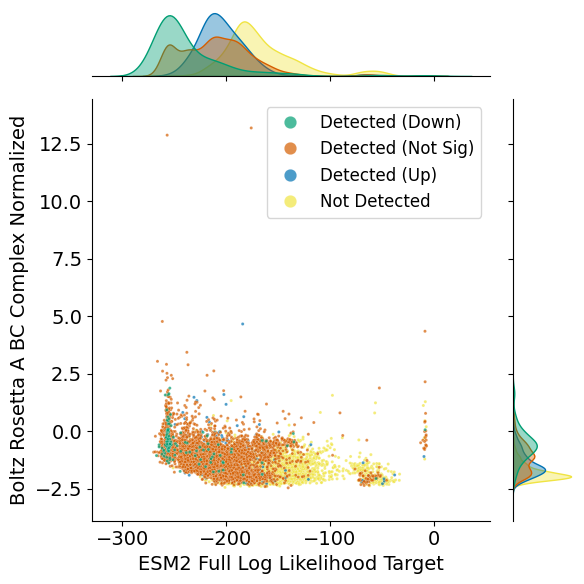

In [22]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def map_four_class_int_to_label(v):
    if pd.isna(v):
        return "Not Detected"
    if v == 0:
        return "Detected (Not Sig)"
    if v == 1:
        return "Detected (Up)"
    if v == -1:
        return "Detected (Down)"
    return "Not Detected"


def ensure_fourclass(results_df):
    if "leah_12k_2fold_threshold_int" not in results_df.columns:
        results_df["leah_12k_2fold_threshold_int"] = results_df["leah_12k_2fold_threshold"].map(
            {"Up": 1, "Not Sig": 0, "Down": -1, np.nan: np.nan}
        )
    if "fourclass" not in results_df.columns:
        results_df["fourclass"] = results_df["leah_12k_2fold_threshold_int"].apply(
            map_four_class_int_to_label
        )
    return results_df


def pretty_label(name):
    return (
        name.replace("_", " ")
            .title()
            .replace("Ll", "Log Likelihood")
            .replace("Car", "CAR")
            .replace("Esm", "ESM")
            .replace("Bc", "BC")
            .replace("Gc", "GC")
            .replace("Dna", "DNA")
    )


def plot_joint_two_features(
    feat_x,
    feat_y,
    metrics_df,
    results_df,
    hue_col="fourclass",          # e.g. "fourclass" or "leah_12k_detected"
    hue_order=None,
    palette=None,
    out_path=None,
):
    # ensure fourclass exists if requested
    if hue_col == "fourclass":
        results_df = ensure_fourclass(results_df)

    # base plotting df
    # add any extras you care about here if needed
    plot_df = metrics_df[[feat_x, feat_y]].copy()
    plot_df = plot_df.dropna(subset=[feat_x, feat_y])
    

    # attach hue column from results_df
    if hue_col == "fourclass":
        h = results_df.loc[plot_df.index, "fourclass"]
        plot_df["hue"] = h
    elif hue_col == "leah_12k_detected":
        # map to nicer labels
        h_raw = results_df.loc[plot_df.index, "leah_12k_detected"].astype(bool)
        plot_df["hue"] = np.where(h_raw, "Detected", "Not Detected")
    else:
        # generic: directly copy that column
        h = results_df.loc[plot_df.index, hue_col]
        plot_df["hue"] = h

    # drop rows with missing hue
    plot_df = plot_df[plot_df["hue"].notna()]

    # default orders and palettes if not provided
    if hue_col == "fourclass":
        default_order = [
            "Detected (Down)",
            "Detected (Not Sig)",
            "Detected (Up)",
            "Not Detected",
        ]
        default_palette = {
            "Detected (Down)": "#009E73",
            "Detected (Not Sig)": "#D55E00",
            "Detected (Up)": "#0072B2",
            "Not Detected": "#F0E442",
        }
        # sort to have nicer layering
        cat_order = {
            "Detected (Down)": 3,
            "Detected (Not Sig)": 1,
            "Detected (Up)": 2,
            "Not Detected": 0,
        }
        plot_df = plot_df.assign(sort_key=plot_df["hue"].map(cat_order))
        plot_df = plot_df.sort_values("sort_key", ascending=True)
    elif hue_col == "leah_12k_detected":
        default_order = ["Detected", "Not Detected"]
        default_palette = {
            "Detected": "#0072B2",
            "Not Detected": "#D55E00",
        }
    else:
        # fall back to sorted unique values and let seaborn choose colors
        default_order = sorted(plot_df["hue"].unique())
        default_palette = None

    if hue_order is None:
        hue_order = default_order
    if palette is None:
        palette = default_palette

    plot_df = plot_df.sort_values(by="hue", ascending=False)

    g = sns.jointplot(
        data=plot_df,
        x=feat_x,
        y=feat_y,
        hue="hue",
        hue_order=hue_order,
        palette=palette,
        kind="scatter",
        s=5,
        alpha=0.7,
        marginal_kws=dict(common_norm=False, fill=True, alpha=0.4),
    )

    # pretty axis labels
    g.ax_joint.set_xlabel(pretty_label(feat_x), fontsize=14)
    g.ax_joint.set_ylabel(pretty_label(feat_y), fontsize=14)

    g.ax_joint.tick_params(axis="x", labelsize=14)
    g.ax_joint.tick_params(axis="y", labelsize=14)

    # legend with larger markers in the right order
    leg = g.ax_joint.get_legend()
    handles = leg.legend_handles
    g.ax_joint.legend(
        handles,
        hue_order,
        markerscale=4,
        fontsize=12,
        title="",
    )

    plt.tight_layout()

    if out_path is None:
        out_path = f"../results/analysis/joint_{feat_x}_{feat_y}_by_{hue_col}.png"

    plt.savefig(out_path, dpi=300)
    # plt.close(g.fig)

# # original: color by fourclass
plot_joint_two_features(
    "esm2_full_LL_target",
    "boltz_rosetta_A_BC_complex_normalized",
    metrics_df,
    results_df,
    hue_col="fourclass",
)

# color by binary leah_12k_detected (mapped to "Detected"/"Not Detected")
# plot_joint_two_features(
#     "dna_sequence_entropy",
#     "dna_gc_content",
#     metrics_df,
#     results_df,
#     hue_col="leah_12k_twist_dna_detected",
#     hue_order=[True, False],
#     palette={True: "#ff7f0e", False: "#1f77b4"},
# )

# feature_cols = [
#     "gravy_score",
#     "aa_sequence_entropy",
#     "seq_kl_vs_human",
#     "num_disulfide_within_chain",
#     "esm2_full_LL_target",
#     "boltz_rosetta_A_BC_complex_normalized",
# ]



In [23]:
# # results_df[~results_df["leah_12k_detected"]][["leah_12k_N6_1", "leah_12k_N6_2", "leah_12k_N6_3", "leah_12k_R6_1", "leah_12k_R6_2", "leah_12k_R6_3"]].describe()
# combined_df = metrics_df.merge(results_df, on=["global_id", "sequence"])

# # combined_df[combined_df["esm2_full_LL_target"] > -150]["leah_12k_detected"].value_counts()
# combined_df["leah_12k_2fold_threshold"] = combined_df["leah_12k_2fold_threshold"].fillna("NaN")
# combined_df[combined_df["esm2_full_LL_target"] > -150]["leah_12k_2fold_threshold"].value_counts()

# def contains_linker(seq):
#     return "GGGS" in seq or "SSGSG" in seq or "GSGSG" in seq

# def contains_repeat(seq):
#     "contains a stretch of 4 characters in a row"
#     for i in range(len(seq) - 3):
#         if seq[i] == seq[i+1] == seq[i+2] == seq[i+3]:
#             return True
#     return False

# combined_df["contains_linker"] = combined_df["sequence"].apply(contains_linker)
# combined_df["contains_repeat"] = combined_df["sequence"].apply(contains_repeat)


# # print gravy by group
# gravy_stats = combined_df.groupby("leah_12k_2fold_threshold")["gravy"].describe()
# print("GRAVY stats by leah_12k_2fold_threshold:")
# print(gravy_stats)
# print()

# removed_df = pd.DataFrame()

# # combined_df[combined_df["esm2_full_LL_target"] > -150][["global_id", "sequence", "esm2_full_LL_target", "leah_12k_detected", "leah_12k_2fold_threshold", "msa_depth", "closest_ab", "contains_linker"]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_goodesm.csv", index=False)

# print("Initial:")
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("ESM2 LL > -150:")
# combined_df = combined_df[combined_df["esm2_full_LL_target"] > -150].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("mean boltz_rosetta_A_BC_complex_normalized")
# print(combined_df["boltz_rosetta_A_BC_complex_normalized"].describe())

# print("Removing seqs with GGGS, SSGSG, GSGSG linkers:")
# removed_df = pd.concat([removed_df, combined_df[combined_df["contains_linker"]]])
# combined_df = combined_df[~combined_df["contains_linker"]].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("Removing seqs with any ab homology:")
# removed_df = pd.concat([removed_df, combined_df[combined_df["closest_ab_pident"] > 0]])
# combined_df = combined_df[combined_df["closest_ab_pident"] == 0].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()

# print("Removing seqs with stretch of 4+ same character in a row:")
# removed_df = pd.concat([removed_df, combined_df[combined_df["contains_repeat"]]])
# combined_df = combined_df[~combined_df["contains_repeat"]].reset_index(drop=True)
# print(f"Total seqs: {len(combined_df)}")
# print(combined_df["leah_12k_2fold_threshold"].value_counts())
# print()


# combined_df[["global_id", "sequence", "esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "leah_12k_detected", "leah_12k_2fold_threshold", "msa_depth",]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_goodesm.csv", index=False)
# removed_df[["global_id", "sequence", "esm2_full_LL_target", "boltz_rosetta_A_BC_complex_normalized", "leah_12k_detected", "leah_12k_2fold_threshold", "msa_depth", "closest_ab_pident", "contains_linker", "contains_repeat"]].sort_values(by=["leah_12k_2fold_threshold", "esm2_full_LL_target"]).to_csv("_tmp_removed.csv", index=False)

In [24]:
# results_df_filtered = results_df[results_df["leah_12k_detected"]].reset_index(drop=True)
# results_df_filtered["leah_12k_2fold_threshold_int"] = results_df_filtered["leah_12k_2fold_threshold"].map({"Up": 1, "Not Sig": 0, "Down": -1})
# metrics_df_filtered = metrics_df[metrics_df["global_id"].isin(results_df_filtered["global_id"])].reset_index(drop=True)
# cols = metrics_df_filtered.columns.drop(["team", "global_id", "sequence", "closest_ab"]).tolist()

# mi_df = pd.DataFrame()
# for col in cols:
#     pre_len = len(metrics_df_filtered)
#     metrics_df_col = metrics_df_filtered[[col]].copy()
#     metrics_df_col = metrics_df_col[~metrics_df_col[col].isna()]
#     post_len = len(metrics_df_col)
#     X = metrics_df_col[col].values.reshape(-1, 1)
#     y = results_df_filtered.loc[metrics_df_col.index, "leah_12k_2fold_threshold_int"].values
#     mi = mutual_info_classif(
#         X,
#         y,
#         random_state=891237,
#         # n_neighbors=5,
#         # discrete_features=False,
#     )
#     sub_df = pd.DataFrame({
#         "metric": col,
#         "mi_vs_leah_12k_2fold_threshold_int": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })
#     mi_df = pd.concat([mi_df, sub_df], axis=0)
# mi_df = mi_df.sort_values("mi_vs_leah_12k_2fold_threshold_int", ascending=False).reset_index(drop=True)
# mi_df.to_csv("../results/analysis/feature_mi_vs_leah_12k_2fold_threshold_int_filtered.csv", index=False)

In [25]:
# # make a new metrics df that averages across each "team"
# # remember, we need to get rid of our non-float cols
# metrics_df_grouped = metrics_df.copy().drop(columns=["global_id", "sequence", "closest_ab"])
# metrics_df_grouped = metrics_df_grouped.dropna()
# print(f"Dropped to {len(metrics_df_grouped)} rows after dropping NA")
# metrics_df_grouped = metrics_df_grouped.groupby("team").mean().reset_index()
# metrics_df_grouped = metrics_df_grouped[metrics_df_grouped["team"] != "Leah Labs"].reset_index(drop=True)
# per_team_df = pd.read_csv("../data/good/master_data_teams.csv", usecols=["team", "confidence", "number_of_unique_seqs_submitted", "number_of_significant_seqs", "percent_of_significant_seqs", "12k_hit_rate_ranking"])

# # now compute mutual information for each metric in metrics_df_grouped with per_team_df["percent_of_significant_seqs"] (continuous)

# from sklearn.feature_selection import mutual_info_regression

# # merge team level metrics with team level percent_of_significant_seqs
# merged_df = metrics_df_grouped.merge(
#     per_team_df[["team", "percent_of_significant_seqs"]],
#     on="team",
#     how="inner",
# )

# # all metric columns (everything except team and target)
# metric_cols = merged_df.columns.drop(["team", "percent_of_significant_seqs"])

# mi_rows = []

# for col in metric_cols:
#     pre_len = len(merged_df)

#     sub = merged_df[[col, "percent_of_significant_seqs"]].dropna()
#     post_len = len(sub)

#     X = sub[[col]].values  # shape (n_samples, 1)
#     y = sub["percent_of_significant_seqs"].values  # continuous target

#     mi = mutual_info_regression(
#         X,
#         y,
#         random_state=891237,
#     )[0]

#     mi_rows.append({
#         "metric": col,
#         "mi_vs_percent_of_significant_seqs": mi,
#         "num_non_nan": post_len,
#         "num_nan": pre_len - post_len,
#     })

# mi_df = pd.DataFrame(mi_rows).sort_values(
#     "mi_vs_percent_of_significant_seqs",
#     ascending=False,
# )

# mi_df.sort_values("mi_vs_percent_of_significant_seqs", ascending=False).reset_index(drop=True).to_csv("../results/analysis/feature_mi_vs_percent_of_significant_seqs_per_team.csv", index=False)